**Importing Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

**Load Dataset**

In [5]:
apple_stock = pd.read_csv("/content/AAPL.csv")
apple_stock

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600
...,...,...,...,...,...,...,...
10463,2022-06-13,132.869995,135.199997,131.440002,131.880005,131.880005,122207100
10464,2022-06-14,133.130005,133.889999,131.479996,132.759995,132.759995,84784300
10465,2022-06-15,134.289993,137.339996,132.160004,135.429993,135.429993,91533000
10466,2022-06-16,132.080002,132.389999,129.039993,130.059998,130.059998,108123900


**Operations**

In [6]:
apple_stock.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600


In [7]:
apple_stock.shape

(10468, 7)

In [10]:
apple_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10468 entries, 0 to 10467
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10468 non-null  object 
 1   Open       10468 non-null  float64
 2   High       10468 non-null  float64
 3   Low        10468 non-null  float64
 4   Close      10468 non-null  float64
 5   Adj Close  10468 non-null  float64
 6   Volume     10468 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 572.6+ KB


In [11]:
apple_stock.describe()

,Open,High,Low,Close,Adj Close,Volume
count,10468.000000,10468.000000,10468.000000,10468.000000,10468.000000,1.046800e+04
mean,14.757987,14.921491,14.594484,14.763533,14.130431,3.308489e+08
std,31.914174,32.289158,31.543959,31.929489,31.637275,3.388418e+08
min,0.049665,0.049665,0.049107,0.049107,0.038329,0.000000e+00
25%,0.283482,0.289286,0.276786,0.283482,0.235462,1.237768e+08
50%,0.474107,0.482768,0.465960,0.475446,0.392373,2.181592e+08
75%,14.953303,15.057143,14.692589,14.901964,12.835269,4.105794e+08
max,182.630005,182.940002,179.119995,182.009995,181.511703,7.421641e+09


In [12]:
apple_stock.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


**Visualize Closing Price Trend**

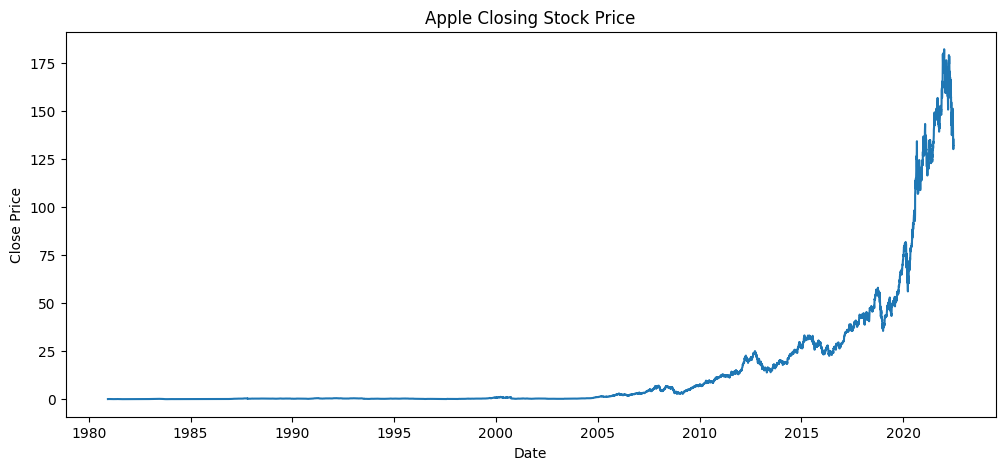

In [17]:
plt.figure(figsize=(12,5))

plt.plot(apple_stock['Date'],apple_stock['Close'])

plt.title('Apple Closing Stock Price')
plt.xlabel('Date')
plt.ylabel('Close Price')

plt.show()

**Volume Trend**

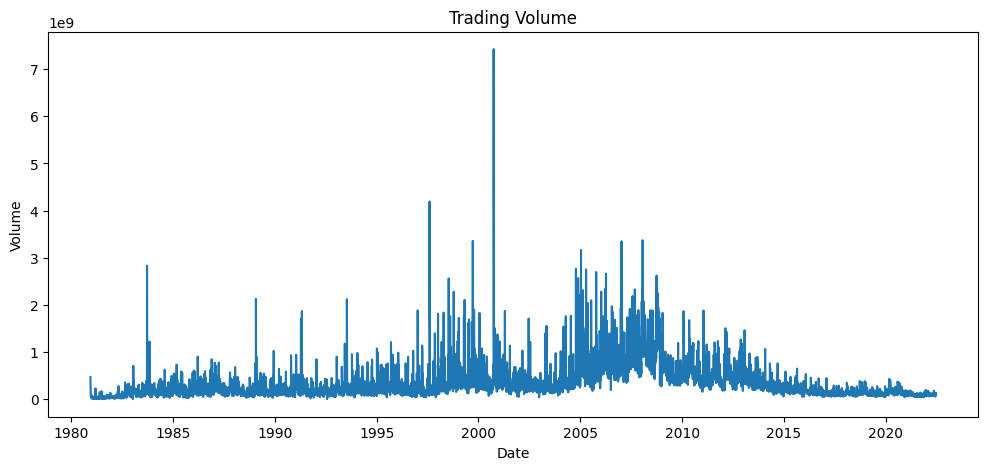

In [18]:
plt.figure(figsize=(12,5))

plt.plot(apple_stock['Date'],apple_stock['Volume'])

plt.title('Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()

**High vs Low Price**

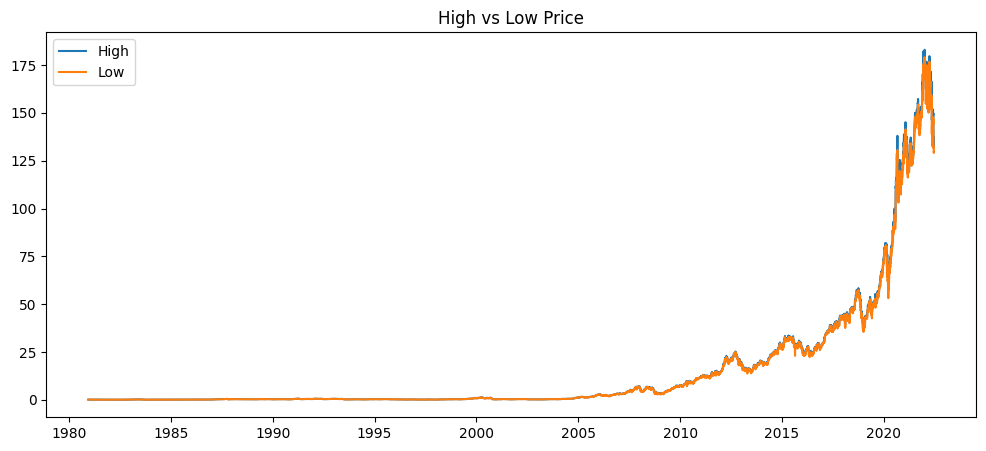

In [19]:
plt.figure(figsize=(12,5))

plt.plot(apple_stock['Date'],apple_stock['High'], label='High')
plt.plot(apple_stock['Date'],apple_stock['Low'], label='Low')

plt.legend()

plt.title('High vs Low Price')

plt.show()

**Correlation Analysis**

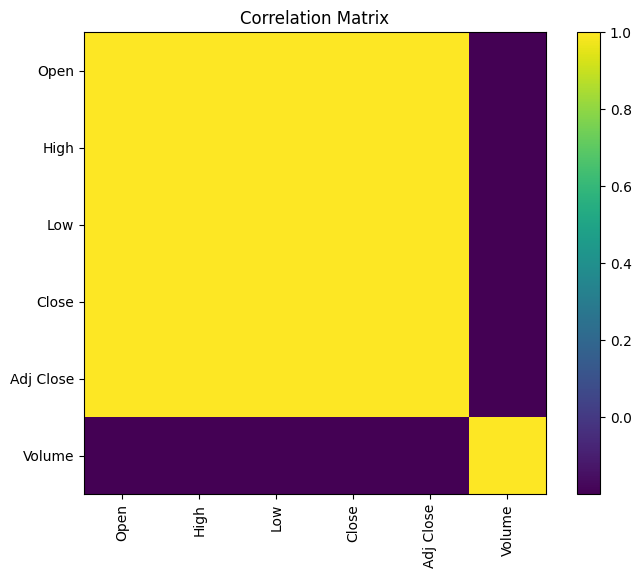

In [20]:
numeric_df = apple_stock.select_dtypes(include=['number'])

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [22]:
apple_stock['Target'] = apple_stock['Close'].shift(-1)

apple_stock.dropna(inplace=True)

In [24]:
X = apple_stock[['Open','High','Low','Volume']]

y = apple_stock['Target']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

**Train Random Forest Model**

In [26]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

**Make Predictions**

In [27]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[35.42572535  0.22894153  3.2480679  13.40288931  0.68901136 70.01432519
  6.82777145  0.3264443   8.01204989  0.38430476]


**Evaluate Model**

Mean absolute error

In [28]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.23616373321394452


RMSE - Root mean square error

In [29]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("RMSE:", rmse)

RMSE: 0.7808256623678919


R² Score

In [30]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.9993704992947531


**Actual vs Predicted Graph**

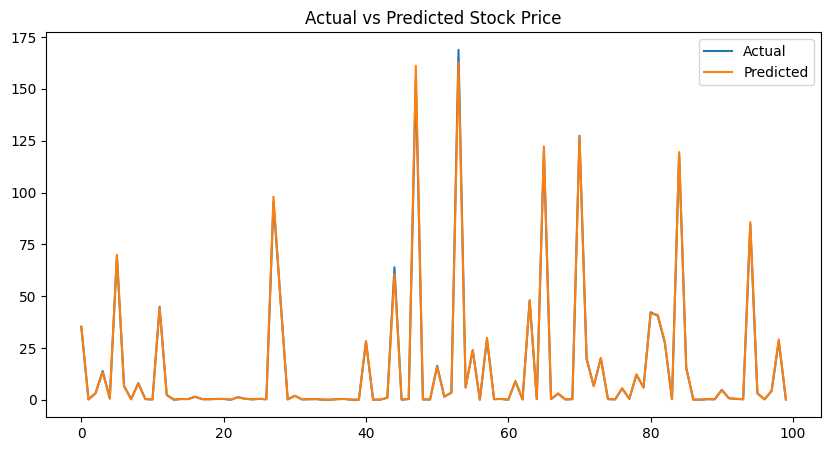

In [31]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100],
         label='Actual')

plt.plot(y_pred[:100],
         label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Stock Price")

plt.show()

**Feature Importance**

In [32]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(importance.sort_values(
    by='Importance',
    ascending=False
))

  Feature  Importance
2     Low    0.541823
1    High    0.290097
0    Open    0.167954
3  Volume    0.000127


**Predict New Stock Price**

In [33]:
new_data = [[190,195,188,50000000]]

prediction = model.predict(new_data)

print("Predicted Next Day Price:",
      prediction[0])

Predicted Next Day Price: 177.50850119999996


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


**Insights**

1.Apple stock prices show a long-term upward trend.

2.High and Low prices strongly influence the next day's closing price.

3.Trading volume affects stock movement.

4.Random Forest achieved strong predictive performance.

5.The model can estimate future stock prices using historical market data.